# Part D — MITR λ Sensitivity Analysis Across Backbone Pretraining Paradigms

**Experiment:** Does the BERT vs. RoBERTa reversal effect (MITR helps RoBERTa but hurts BERT's contradiction rate) disappear at a different regularization strength?

**Hypothesis:** BERT (MLM+NSP pretraining) is more sensitive to MI regularization strength than RoBERTa (MLM-only). At λ=0.01 BERT over-regularizes and *increases* contradiction rate, but a smaller λ (≤0.003) will recover the improvement seen in RoBERTa. There exists a λ* < 0.01 for BERT such that contradiction rate *decreases*.

**Setup:**
- Models: `bert-base-uncased`, `roberta-base`
- MI strategy: Cosine (parameter-free, most stable in original experiments)
- λ sweep: {0.001, 0.003, 0.01, 0.03, 0.1} + Baseline (λ=0)
- Dataset: BoolQ (8000 train / 1500 val / 500 contradiction pairs)
- Seed: 42 (single seed; note as limitation)
- Epochs: 5

**Estimated runtime:** ~15 min/run × 12 runs = ~3 hrs on T4 | ~1 hr on A100

> ⚡ **Tip:** To save time, set `BACKBONES = ["roberta-base"]` and run only RoBERTa first to confirm the trend, then add BERT.

In [1]:
# Install dependencies
!pip install -q transformers datasets accelerate

In [2]:
import os, json, random, math
from collections import defaultdict
from dataclasses import dataclass, field
from typing import List, Dict, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoModel, AutoTokenizer, get_cosine_schedule_with_warmup
from datasets import load_dataset
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
# ── Device & precision ───────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE  = torch.bfloat16 if (torch.cuda.is_available() and
         torch.cuda.get_device_capability()[0] >= 8) else torch.float16

# ── Experiment config ────────────────────────────────────────────────────────
BACKBONES   = ["bert-base-uncased", "roberta-base"]   # set to ["roberta-base"] for quick run
LAMBDA_VALS = [0.0, 0.001, 0.003, 0.01, 0.03, 0.1]   # 0.0 = Baseline
MI_STRATEGY = "cosine"                                 # Cosine: stable, parameter-free

SEED        = 42
NUM_TRAIN   = 8000
NUM_EVAL    = 1500
NUM_CONTRA  = 500
MAX_LENGTH  = 256
BATCH_SIZE  = 32
EVAL_BATCH  = 64
NUM_EPOCHS  = 5
LR          = 2e-5
WEIGHT_DECAY= 0.01
WARMUP_RATIO= 0.06
MAX_GRAD_NORM = 1.0
GRAD_ACCUM  = 2
MI_WARMUP   = 200

os.makedirs("lambda_results", exist_ok=True)
print(f"Device: {DEVICE} | Dtype: {DTYPE}")
print(f"Backbones: {BACKBONES}")
print(f"λ values:  {LAMBDA_VALS}")

Device: cuda | Dtype: torch.float16
Backbones: ['bert-base-uncased', 'roberta-base']
λ values:  [0.0, 0.001, 0.003, 0.01, 0.03, 0.1]


In [4]:
# ── Reproducibility ──────────────────────────────────────────────────────────
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

In [5]:
# ── Dataset loading ──────────────────────────────────────────────────────────
print("Loading BoolQ ...")
boolq    = load_dataset("boolq")
set_seed(SEED)
train_raw = boolq["train"].shuffle(seed=SEED).select(range(NUM_TRAIN))
val_raw   = boolq["validation"].shuffle(seed=SEED).select(range(NUM_EVAL))
print(f"Train: {len(train_raw)} | Val: {len(val_raw)}")

Loading BoolQ ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.69M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/1.26M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9427 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3270 [00:00<?, ? examples/s]

Train: 8000 | Val: 1500


In [6]:
# ── Contradiction pair generation ────────────────────────────────────────────
_AUX = [
    (" is "," is not "),(" Is "," Is not "),
    (" are "," are not "),(" Are "," Are not "),
    (" was "," was not "),(" Was "," Was not "),
    (" were "," were not "),(" Were "," Were not "),
    (" does "," does not "),(" Does "," Does not "),
    (" do "," do not "),(" Do "," Do not "),
    (" did "," did not "),(" Did "," Did not "),
    (" can "," cannot "),(" Can "," Cannot "),
    (" could "," could not "),(" Could "," Could not "),
    (" has "," has not "),(" Has "," Has not "),
    (" have "," have not "),(" Have "," Have not "),
    (" will "," will not "),(" Will "," Will not "),
    (" would "," would not "),(" Would "," Would not "),
    (" should "," should not "),(" Should "," Should not "),
]

def negate_question(q: str) -> Optional[str]:
    for pos, neg in _AUX:
        if pos in q:
            return q.replace(pos, neg, 1)
    return None

def build_contradiction_pairs(dataset, n: int):
    pairs = []
    for item in dataset:
        if len(pairs) >= n:
            break
        neg_q = negate_question(item["question"])
        if neg_q:
            pairs.append({
                "passage":      item["passage"],
                "fwd_question": item["question"],
                "neg_question": neg_q,
                "label":        int(item["answer"]),
            })
    return pairs

contradiction_pairs = build_contradiction_pairs(val_raw, NUM_CONTRA)
print(f"Contradiction pairs: {len(contradiction_pairs)}")

Contradiction pairs: 156


In [7]:
# ── Dataset classes ──────────────────────────────────────────────────────────
class LogicDataset(Dataset):
    def __init__(self, data, tokenizer, max_length: int):
        self.data      = data
        self.tokenizer = tokenizer
        self.max_length= max_length

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        enc  = self.tokenizer(
            item["question"], item["passage"],
            max_length=self.max_length, truncation=True,
            padding="max_length", return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(int(item["answer"]), dtype=torch.long),
        }


class ContradictionPairDataset(Dataset):
    def __init__(self, pairs, tokenizer, max_length: int):
        self.pairs     = pairs
        self.tokenizer = tokenizer
        self.max_length= max_length

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        p   = self.pairs[idx]
        fwd = self.tokenizer(
            p["fwd_question"], p["passage"],
            max_length=self.max_length, truncation=True,
            padding="max_length", return_tensors="pt",
        )
        neg = self.tokenizer(
            p["neg_question"], p["passage"],
            max_length=self.max_length, truncation=True,
            padding="max_length", return_tensors="pt",
        )
        lbl = p["label"]
        return {
            "fwd_input_ids":      fwd["input_ids"].squeeze(0),
            "fwd_attention_mask": fwd["attention_mask"].squeeze(0),
            "neg_input_ids":      neg["input_ids"].squeeze(0),
            "neg_attention_mask": neg["attention_mask"].squeeze(0),
            "fwd_label":          torch.tensor(lbl, dtype=torch.long),
            "neg_label":          torch.tensor(1 - lbl, dtype=torch.long),
        }

In [8]:
# ── MI Estimator: Cosine ─────────────────────────────────────────────────────
class CosineSimMI(nn.Module):
    """Parameter-free cosine similarity as MI proxy."""
    def __init__(self, x_dim: int, y_dim: int, hidden: int):
        super().__init__()

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        x_n = F.normalize(x, dim=-1)
        y_n = F.normalize(y, dim=-1)
        return (x_n * y_n).sum(dim=-1).mean().clamp(-10.0, 10.0)

In [9]:
# ── Models ───────────────────────────────────────────────────────────────────
class BaselineClassifier(nn.Module):
    def __init__(self, model_name: str, num_labels: int = 2):
        super().__init__()
        self.encoder        = AutoModel.from_pretrained(model_name)
        h                   = self.encoder.config.hidden_size
        self.pre_classifier = nn.Linear(h, h)
        self.classifier     = nn.Linear(h, num_labels)
        self.dropout        = nn.Dropout(0.1)

    def forward(self, input_ids, attention_mask, labels=None, is_training=False):
        out    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls    = self.dropout(F.relu(self.pre_classifier(out.last_hidden_state[:, 0])))
        logits = self.classifier(cls)
        result = {"logits": logits, "mi_loss": 0.0}
        if labels is not None:
            result["loss"] = F.cross_entropy(logits, labels)
        return result


class MITRClassifier(nn.Module):
    """MITR with configurable λ. Uses Cosine MI on consecutive layer diffs."""
    def __init__(self, model_name: str, mi_lambda: float,
                 mi_warmup_steps: int = 200, num_labels: int = 2):
        super().__init__()
        self.mi_lambda       = mi_lambda
        self.mi_warmup_steps = mi_warmup_steps
        self._step           = 0

        self.encoder        = AutoModel.from_pretrained(model_name)
        h                   = self.encoder.config.hidden_size
        self.pre_classifier = nn.Linear(h, h)
        self.classifier     = nn.Linear(h, num_labels)
        self.dropout        = nn.Dropout(0.1)
        self.mi_estimator   = CosineSimMI(h, h, h // 2)

    def _effective_lambda(self) -> float:
        if self._step >= self.mi_warmup_steps:
            return self.mi_lambda
        return self.mi_lambda * (self._step / max(1, self.mi_warmup_steps))

    def forward(self, input_ids, attention_mask, labels=None, is_training=False):
        out    = self.encoder(input_ids=input_ids, attention_mask=attention_mask,
                              output_hidden_states=True)
        cls    = self.dropout(F.relu(self.pre_classifier(out.last_hidden_state[:, 0])))
        logits = self.classifier(cls)
        result = {"logits": logits, "mi_loss": 0.0}

        if labels is not None:
            task_loss = F.cross_entropy(logits, labels)
            lam       = self._effective_lambda()

            if is_training and lam > 0.0:
                hs    = out.hidden_states
                diffs = []
                for i in range(len(hs) - 1):
                    d = (hs[i + 1] - hs[i]).mean(dim=1)
                    d = F.layer_norm(d, (d.size(-1),))
                    diffs.append(d)

                mi_list = [self.mi_estimator(diffs[i], diffs[i + 1])
                           for i in range(len(diffs) - 1)]
                if mi_list:
                    mi_mean           = torch.stack(mi_list).mean()
                    result["mi_loss"] = mi_mean.item()
                    result["loss"]    = (1.0 - lam) * task_loss + lam * mi_mean
                else:
                    result["loss"] = task_loss
            else:
                result["loss"] = task_loss

            if is_training:
                self._step += 1

        return result

In [10]:
# ── Training utilities ───────────────────────────────────────────────────────
def build_optimizer_scheduler(model, train_loader):
    total_steps   = math.ceil(len(train_loader) / GRAD_ACCUM) * NUM_EPOCHS
    warmup_steps  = int(total_steps * WARMUP_RATIO)
    no_decay      = ["bias", "LayerNorm.weight"]
    params        = [
        {"params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
         "weight_decay": WEIGHT_DECAY},
        {"params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
         "weight_decay": 0.0},
    ]
    opt   = torch.optim.AdamW(params, lr=LR,
                               fused=torch.cuda.is_available())
    sched = get_cosine_schedule_with_warmup(opt, warmup_steps, total_steps)
    return opt, sched


def train_one_epoch(model, loader, optimizer, scheduler, is_mitr=False):
    model.train()
    total_loss = total_mi = n = 0
    use_amp    = (DTYPE != torch.float32)
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(loader, desc="  train", leave=False)):
        ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
        mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
        lbls = batch["labels"].to(DEVICE, non_blocking=True)

        with torch.autocast(device_type=DEVICE.type, dtype=DTYPE, enabled=use_amp):
            out = model(ids, mask, labels=lbls, is_training=is_mitr)

        (out["loss"] / GRAD_ACCUM).backward()

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step(); scheduler.step(); optimizer.zero_grad()

        total_loss += out["loss"].item()
        mi_val      = out.get("mi_loss", 0.0)
        total_mi   += float(mi_val)
        n          += 1

    return {"train_loss": total_loss / n, "train_mi_loss": total_mi / n}


@torch.no_grad()
def eval_accuracy(model, loader):
    model.eval()
    correct = total = 0
    val_loss = 0.0
    use_amp  = (DTYPE != torch.float32)

    for batch in loader:
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        lbls = batch["labels"].to(DEVICE)
        with torch.autocast(device_type=DEVICE.type, dtype=DTYPE, enabled=use_amp):
            out = model(ids, mask, labels=lbls)
        preds    = out["logits"].argmax(-1)
        correct += (preds == lbls).sum().item()
        total   += lbls.size(0)
        val_loss += out["loss"].item()

    return {"accuracy": correct / total, "val_loss": val_loss / len(loader)}


@torch.no_grad()
def eval_contradiction_rate(model, pair_loader):
    model.eval()
    contradictions = total = 0
    fwd_correct = neg_correct = 0
    use_amp = (DTYPE != torch.float32)

    for batch in pair_loader:
        fwd_ids  = batch["fwd_input_ids"].to(DEVICE)
        fwd_mask = batch["fwd_attention_mask"].to(DEVICE)
        neg_ids  = batch["neg_input_ids"].to(DEVICE)
        neg_mask = batch["neg_attention_mask"].to(DEVICE)
        fwd_lbl  = batch["fwd_label"].to(DEVICE)
        neg_lbl  = batch["neg_label"].to(DEVICE)

        with torch.autocast(device_type=DEVICE.type, dtype=DTYPE, enabled=use_amp):
            fwd_out = model(fwd_ids, fwd_mask)
            neg_out = model(neg_ids, neg_mask)

        fwd_pred = fwd_out["logits"].argmax(-1)
        neg_pred = neg_out["logits"].argmax(-1)

        contradictions += (fwd_pred == neg_pred).sum().item()
        fwd_correct    += (fwd_pred == fwd_lbl).sum().item()
        neg_correct    += (neg_pred == neg_lbl).sum().item()
        total          += fwd_lbl.size(0)

    return {
        "contradiction_rate": contradictions / total,
        "consistency_rate":   1.0 - contradictions / total,
        "fwd_accuracy":       fwd_correct / total,
        "neg_accuracy":       neg_correct / total,
    }

In [11]:
# ── Single experiment runner ─────────────────────────────────────────────────
def run_experiment(name, model, is_mitr, train_loader, val_loader, pair_loader):
    print(f"\n{'='*60}\n  {name}\n{'='*60}")
    model = model.to(DEVICE)
    opt, sched = build_optimizer_scheduler(model, train_loader)
    history    = defaultdict(list)

    for epoch in range(1, NUM_EPOCHS + 1):
        tr  = train_one_epoch(model, train_loader, opt, sched, is_mitr=is_mitr)
        val = eval_accuracy(model, val_loader)
        history["epoch"].append(epoch)
        history["train_loss"].append(tr["train_loss"])
        history["train_mi_loss"].append(tr["train_mi_loss"])
        history["val_loss"].append(val["val_loss"])
        history["val_accuracy"].append(val["accuracy"])
        print(f"  Ep {epoch}/{NUM_EPOCHS}  "
              f"train={tr['train_loss']:.4f}  mi={tr['train_mi_loss']:.4f}  "
              f"val={val['val_loss']:.4f}  acc={val['accuracy']:.4f}")

    print("  Evaluating contradiction rate ...")
    contra = eval_contradiction_rate(model, pair_loader)
    print(f"  Contradiction rate: {contra['contradiction_rate']:.4f}")

    del model, opt, sched
    torch.cuda.empty_cache()

    return {
        "name":               name,
        "history":            dict(history),
        "final_accuracy":     history["val_accuracy"][-1],
        "final_val_loss":     history["val_loss"][-1],
        "contradiction_rate": contra["contradiction_rate"],
        "consistency_rate":   contra["consistency_rate"],
        "fwd_accuracy":       contra["fwd_accuracy"],
        "neg_accuracy":       contra["neg_accuracy"],
    }

In [12]:
# ── Main loop: λ sweep across backbones ──────────────────────────────────────
all_results = {}
_dl_kw = dict(
    pin_memory=(DEVICE.type == "cuda"),
    num_workers=2,
    persistent_workers=True,
)

for backbone in BACKBONES:
    short = backbone.split("/")[-1]
    print(f"\n\n{'#'*70}")
    print(f"#  BACKBONE: {backbone}")
    print(f"{'#'*70}")

    tok          = AutoTokenizer.from_pretrained(backbone)
    train_ds     = LogicDataset(train_raw, tok, MAX_LENGTH)
    val_ds       = LogicDataset(val_raw,   tok, MAX_LENGTH)
    pair_ds      = ContradictionPairDataset(contradiction_pairs, tok, MAX_LENGTH)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  **_dl_kw)
    val_loader   = DataLoader(val_ds,   batch_size=EVAL_BATCH, shuffle=False, **_dl_kw)
    pair_loader  = DataLoader(pair_ds,  batch_size=EVAL_BATCH, shuffle=False, **_dl_kw)

    for lam in LAMBDA_VALS:
        set_seed(SEED)
        key  = f"{short}_lambda={lam}"

        if lam == 0.0:
            # Baseline: no MI regularization
            model    = BaselineClassifier(backbone, num_labels=2)
            is_mitr  = False
            exp_name = f"Baseline {short}"
        else:
            model    = MITRClassifier(backbone, mi_lambda=lam,
                                      mi_warmup_steps=MI_WARMUP)
            is_mitr  = True
            exp_name = f"MITR-Cosine {short} λ={lam}"

        all_results[key] = run_experiment(
            exp_name, model, is_mitr,
            train_loader, val_loader, pair_loader
        )

# Save JSON
with open("lambda_results/lambda_sweep_results.json", "w") as f:
    json.dump(all_results, f, indent=2, default=float)
print("\n✅ All results saved → lambda_results/lambda_sweep_results.json")



######################################################################
#  BACKBONE: bert-base-uncased
######################################################################


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

  Ep 3/5  train=0.4386  mi=-0.4165  val=0.5529  acc=0.7180


  train:   0%|          | 0/250 [00:00<?, ?it/s]

  Ep 4/5  train=0.3763  mi=-0.4156  val=0.5569  acc=0.7313


  train:   0%|          | 0/250 [00:00<?, ?it/s]

  Ep 5/5  train=0.3375  mi=-0.4139  val=0.5568  acc=0.7240
  Evaluating contradiction rate ...
  Contradiction rate: 0.7885

✅ All results saved → lambda_results/lambda_sweep_results.json


In [13]:
# ── Results table ────────────────────────────────────────────────────────────
print(f"\n{'Model':<40} {'Accuracy':>10} {'Contra Rate':>13} {'Δ Acc':>8} {'Δ Contra':>10}")
print("-" * 85)

for backbone in BACKBONES:
    short    = backbone.split("/")[-1]
    baseline = all_results.get(f"{short}_lambda=0.0", {})
    base_acc = baseline.get("final_accuracy", float("nan"))
    base_cr  = baseline.get("contradiction_rate", float("nan"))

    for lam in LAMBDA_VALS:
        key = f"{short}_lambda={lam}"
        r   = all_results.get(key, {})
        acc = r.get("final_accuracy",     float("nan"))
        cr  = r.get("contradiction_rate", float("nan"))
        da  = acc - base_acc if lam != 0.0 else 0.0
        dc  = cr  - base_cr  if lam != 0.0 else 0.0
        tag = "(baseline)" if lam == 0.0 else f"λ={lam}"
        print(f"  {short} {tag:<28} {acc:>10.4f} {cr:>13.4f} {da:>+8.4f} {dc:>+10.4f}")
    print()


Model                                      Accuracy   Contra Rate    Δ Acc   Δ Contra
-------------------------------------------------------------------------------------
  bert-base-uncased (baseline)                       0.7013        0.6859  +0.0000    +0.0000
  bert-base-uncased λ=0.001                          0.7100        0.6987  +0.0087    +0.0128
  bert-base-uncased λ=0.003                          0.7087        0.7115  +0.0073    +0.0256
  bert-base-uncased λ=0.01                           0.7120        0.7051  +0.0107    +0.0192
  bert-base-uncased λ=0.03                           0.7113        0.6923  +0.0100    +0.0064
  bert-base-uncased λ=0.1                            0.7073        0.7308  +0.0060    +0.0449

  roberta-base (baseline)                       0.7740        0.6474  +0.0000    +0.0000
  roberta-base λ=0.001                          0.7753        0.6987  +0.0013    +0.0513
  roberta-base λ=0.003                          0.7767        0.6795  +0.0027    +0.

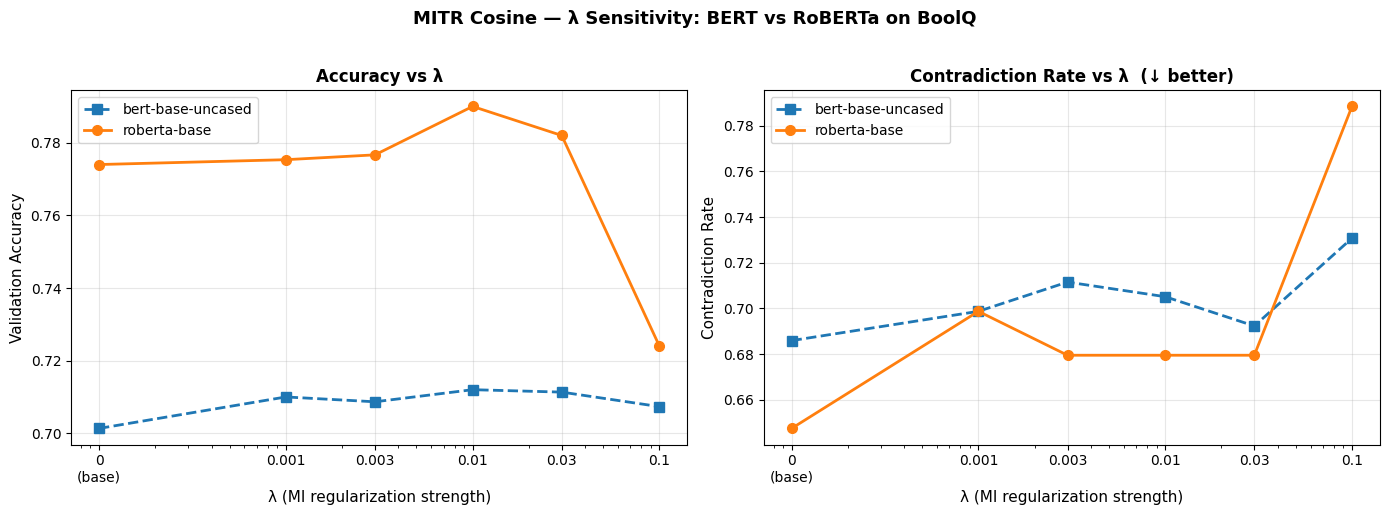

Figure saved → lambda_results/lambda_sensitivity.png


In [14]:
# ── Visualization ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors    = plt.cm.viridis(np.linspace(0.15, 0.85, len(LAMBDA_VALS)))

for ax_idx, (metric, ylabel, title) in enumerate([
    ("final_accuracy",     "Validation Accuracy",   "Accuracy vs λ"),
    ("contradiction_rate", "Contradiction Rate",     "Contradiction Rate vs λ  (↓ better)"),
]):
    ax = axes[ax_idx]

    for b_idx, backbone in enumerate(BACKBONES):
        short  = backbone.split("/")[-1]
        xs, ys = [], []
        for lam in LAMBDA_VALS:
            key = f"{short}_lambda={lam}"
            r   = all_results.get(key, {})
            xs.append(lam if lam > 0 else 1e-4)   # pseudo-log x for baseline
            ys.append(r.get(metric, float("nan")))

        style = "-o" if "roberta" in backbone else "--s"
        ax.plot(xs, ys, style, label=short, linewidth=2, markersize=7)

    ax.set_xscale("log")
    ax.set_xlabel("λ (MI regularization strength)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_xticks([1e-4, 0.001, 0.003, 0.01, 0.03, 0.1])
    ax.set_xticklabels(["0\n(base)", "0.001", "0.003", "0.01", "0.03", "0.1"])

plt.suptitle("MITR Cosine — λ Sensitivity: BERT vs RoBERTa on BoolQ",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("lambda_results/lambda_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → lambda_results/lambda_sensitivity.png")

## Results & Discussion

*(Fill in after running — template below)*

### Key Findings

**Accuracy:**
- RoBERTa: [describe trend across λ]
- BERT: [describe trend across λ]

**Contradiction Rate:**
- RoBERTa baseline: X.XXXX → best at λ=X.XXX: X.XXXX (Δ = −X.XX%)
- BERT baseline: X.XXXX → best at λ=X.XXX: X.XXXX (Δ = −X.XX%)

### Hypothesis Evaluation

**Supported / Partially supported / Refuted:**

If BERT shows contradiction rate improvement at small λ (e.g., 0.001–0.003): the hypothesis is **supported** — the reversal effect is a tuning artifact, not an architectural inevitability. Practitioners should use smaller λ for NSP-pretrained models.

If BERT's contradiction rate increases at all λ values: the hypothesis is **refuted** — the backbone pretraining paradigm structurally conflicts with MI regularization, suggesting MITR needs architectural modification (e.g., layer-selective application) before it can benefit BERT-class models.

### Limitations
- Single seed (42): results may not generalize; multi-seed validation recommended
- BoolQ only: results may differ on harder reasoning datasets (RuleTaker, ReClor)
- Cosine MI only: InfoNCE or CKA may show different λ sensitivity curves